# Fourier Transform — intuition, internal working, Manim animations, and image editing

This notebook is built as a **visual learning path** for the Fourier Transform.

You will learn:

1. The intuition: “any signal is a recipe made of waves.”
2. The internal working: how the transform measures the amount of each wave.
3. A real-world analogy: a prism, audio equalizer, and cooking recipe.
4. How the Discrete Fourier Transform is computed from scratch.
5. How the Fast Fourier Transform is used in practice.
6. How Fourier ideas are used in image editing: blur, sharpen, compression, denoising, and frequency-domain filtering.
7. How to animate the key ideas with **Manim** and plot them with **Matplotlib**.

> Mental model: the Fourier Transform is a **wave detector**.  
> It asks: “How much of frequency 0, frequency 1, frequency 2, ... is present in this signal?”

## 0. Setup

The Matplotlib and NumPy parts work in a normal Python/Jupyter environment.

The Manim animation cells are optional. They need Manim installed plus a working video renderer. In Jupyter, Manim provides a `%%manim` cell magic, so animation code can live directly inside notebook cells.

In [ ]:
# Uncomment if you are running in a fresh environment.
# In Google Colab, Manim may need additional system packages; see Manim's Colab/Jupyter docs.

# !pip install numpy matplotlib scipy pillow scikit-image ipywidgets manim

In [9]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)

def set_plot(title=None, xlabel=None, ylabel=None):
    if title:
        plt.title(title)
    if xlabel:
        plt.xlabel(xlabel)
    if ylabel:
        plt.ylabel(ylabel)
    plt.grid(True, alpha=0.25)
    plt.tight_layout()

def normalize01(x):
    x = np.asarray(x, dtype=float)
    return (x - x.min()) / (x.max() - x.min() + 1e-12)

## 1. The core intuition: a signal as a recipe of waves

Imagine you taste a soup and want to know the recipe.

You cannot see the salt, pepper, onion, and tomato separately. You only taste the final soup.  
The Fourier Transform does a similar job:

- Input: a mixed signal.
- Output: the “ingredients” of the signal.
- Ingredients: sine and cosine waves at different frequencies.
- Amounts: amplitudes.
- Timing/shift: phases.

Another analogy:

| Real world object | Fourier idea |
|---|---|
| White light through a prism | Split into colors/frequencies |
| Audio equalizer | Boost/cut low, mid, high frequencies |
| Music chord | Mixture of notes |
| Image blur | Remove high spatial frequencies |
| Image sharpen | Boost high spatial frequencies |
| JPEG-like compression | Keep important frequency coefficients, discard weaker ones |

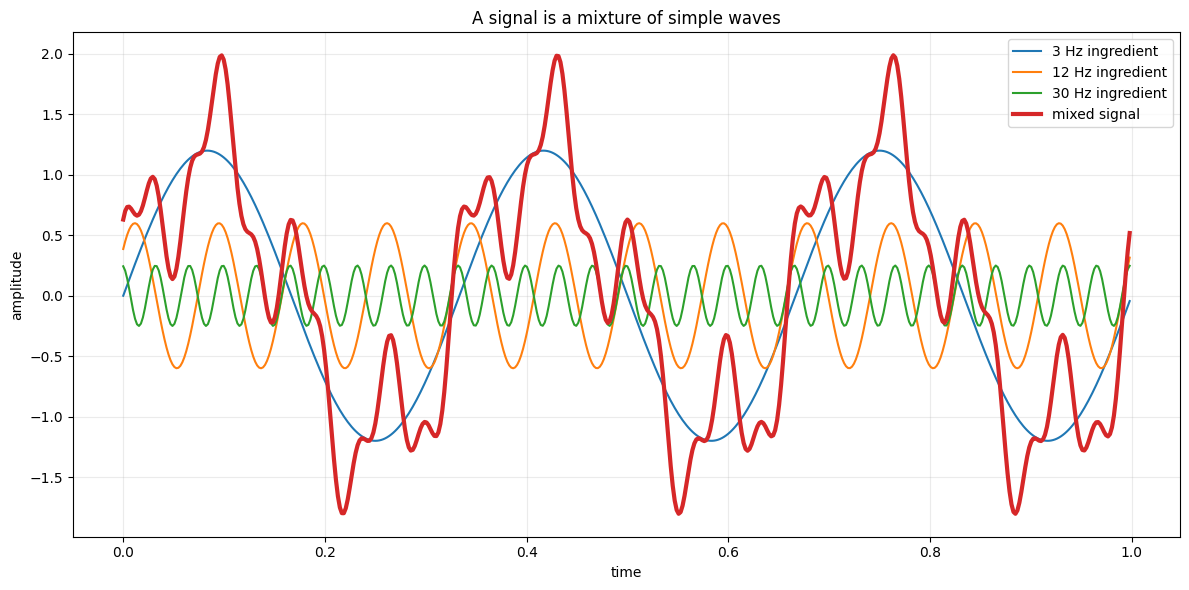

In [10]:
# A signal made from three wave ingredients.

duration = 1.0
sample_rate = 512
t = np.linspace(0, duration, int(sample_rate * duration), endpoint=False)

f1, f2, f3 = 3, 12, 30
component_1 = 1.2 * np.sin(2*np.pi*f1*t)
component_2 = 0.6 * np.sin(2*np.pi*f2*t + 0.7)
component_3 = 0.25 * np.sin(2*np.pi*f3*t + 1.8)
signal = component_1 + component_2 + component_3

plt.figure(figsize=(12, 6))
plt.plot(t, component_1, label=f"{f1} Hz ingredient")
plt.plot(t, component_2, label=f"{f2} Hz ingredient")
plt.plot(t, component_3, label=f"{f3} Hz ingredient")
plt.plot(t, signal, linewidth=3, label="mixed signal")
set_plot("A signal is a mixture of simple waves", "time", "amplitude")
plt.legend()
plt.show()

## 2. The hidden trick: “try every wave and measure how well it matches”

The Fourier Transform does not magically “see” frequencies.

It tries a wave of a certain frequency and asks:

> “Does this wave line up with the signal?”

If yes, the dot product/correlation is large.  
If not, positive and negative parts cancel out.

This is like using many keys on a keyring. Most keys do not open the lock. The matching key clicks.

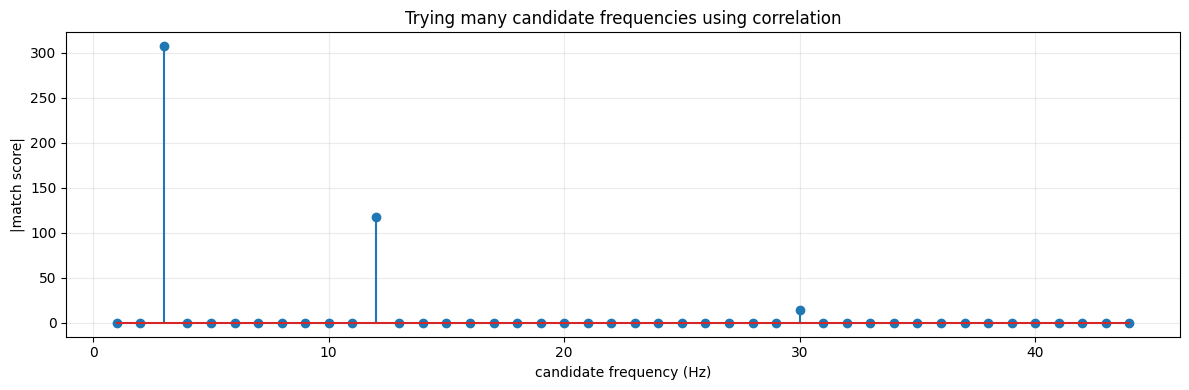

Strong peaks should appear near: 3 12 30 Hz


In [11]:
# Correlation with candidate sine waves.
# Large correlation means the candidate frequency is present in the signal.

candidate_freqs = np.arange(1, 45)
scores = []

for f in candidate_freqs:
    candidate = np.sin(2*np.pi*f*t)
    score = np.dot(signal, candidate)
    scores.append(score)

scores = np.array(scores)

plt.figure(figsize=(12, 4))
plt.stem(candidate_freqs, np.abs(scores))
set_plot("Trying many candidate frequencies using correlation", "candidate frequency (Hz)", "|match score|")
plt.show()

print("Strong peaks should appear near:", f1, f2, f3, "Hz")

## 3. Why sine and cosine both matter

A sine wave can be shifted left or right.

If we only compare with sine waves, we may miss a wave that has the right frequency but the wrong shift.  
So Fourier uses two measuring rulers:

- cosine ruler
- sine ruler

Together they measure both:

- **magnitude**: how much of the frequency exists
- **phase**: where the wave starts / how it is shifted

The elegant way to combine sine and cosine is to use a complex exponential:

\[
e^{-i2\pi f t} = \cos(2\pi f t) - i\sin(2\pi f t)
\]

That rotating complex number is the basis of the Fourier Transform.

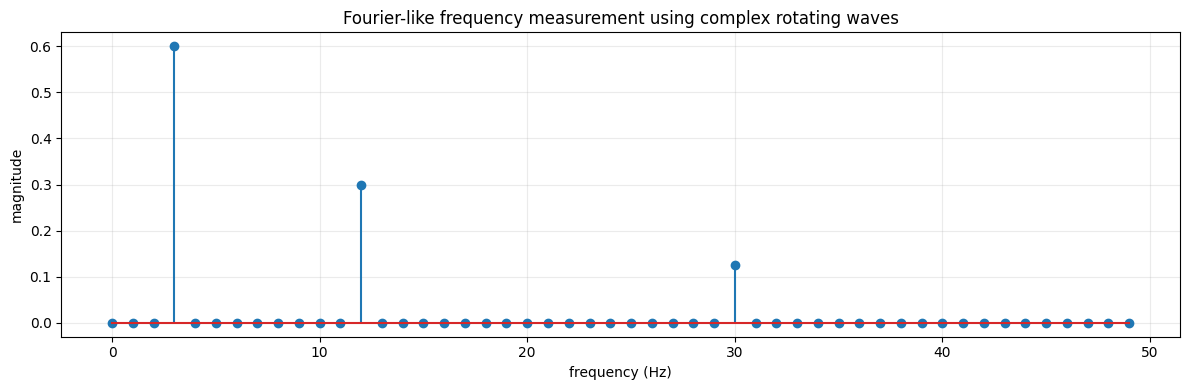

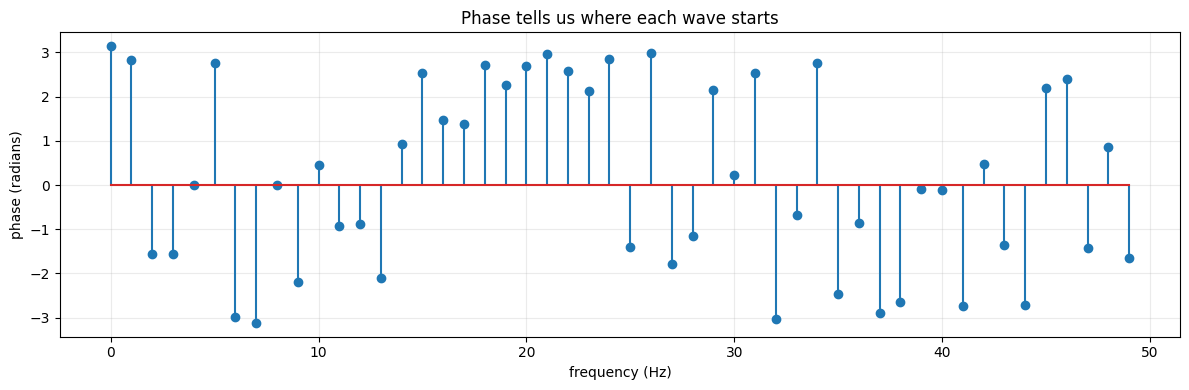

In [12]:
# Same idea, but measuring both sine and cosine parts.
# This produces a complex coefficient for each frequency.

candidate_freqs = np.arange(0, 50)
coeffs = []

for f in candidate_freqs:
    basis = np.exp(-1j * 2*np.pi*f*t)
    coeff = np.sum(signal * basis) / len(signal)
    coeffs.append(coeff)

coeffs = np.array(coeffs)
magnitudes = np.abs(coeffs)
phases = np.angle(coeffs)

plt.figure(figsize=(12, 4))
plt.stem(candidate_freqs, magnitudes)
set_plot("Fourier-like frequency measurement using complex rotating waves", "frequency (Hz)", "magnitude")
plt.show()

plt.figure(figsize=(12, 4))
plt.stem(candidate_freqs, phases)
set_plot("Phase tells us where each wave starts", "frequency (Hz)", "phase (radians)")
plt.show()

## 4. The winding-machine intuition

This is one of the best visual ways to understand the Fourier Transform.

Take a signal and wrap it around a circle at a candidate frequency.

- If the winding frequency is wrong, the wrapped signal spreads around and its center of mass stays near zero.
- If the winding frequency is right, the wrapped signal becomes lopsided and its center of mass moves away from zero.

The Fourier coefficient is essentially that center of mass.

So the Fourier Transform asks:

> “At which winding frequencies does the signal’s center of mass move away from zero?”

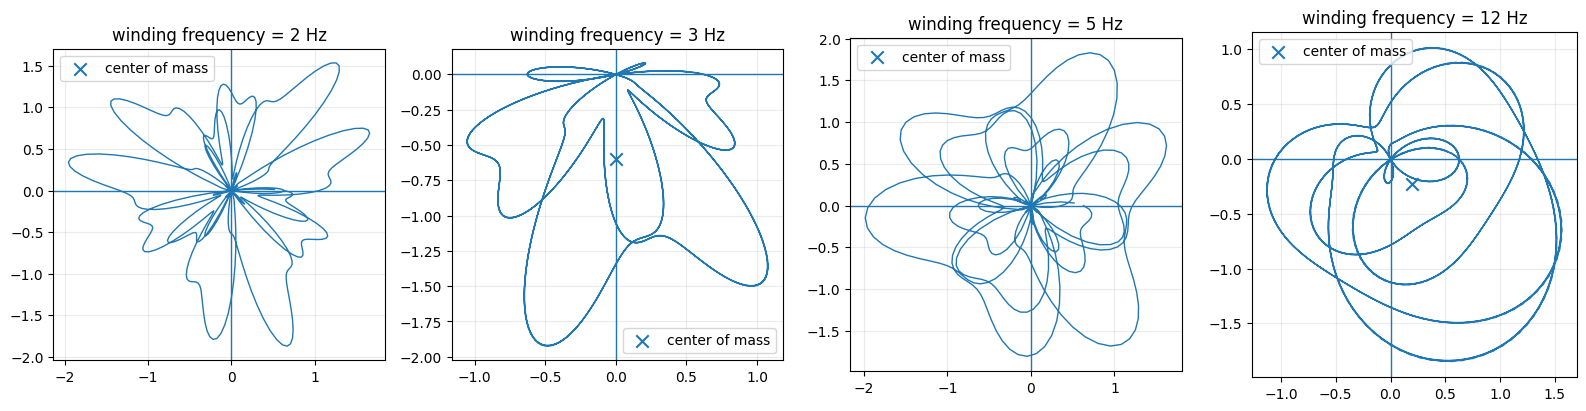

In [13]:
def winding_points(x, signal_values, winding_frequency):
    # Wrap a real-valued signal around the complex plane.
    # x is normalized time.
    return signal_values * np.exp(-1j * 2*np.pi*winding_frequency*x)

def plot_winding_grid(freqs):
    fig, axes = plt.subplots(1, len(freqs), figsize=(4*len(freqs), 4))
    if len(freqs) == 1:
        axes = [axes]
    for ax, wf in zip(axes, freqs):
        z = winding_points(t, signal, wf)
        center = z.mean()
        ax.plot(z.real, z.imag, linewidth=1)
        ax.scatter([center.real], [center.imag], s=80, marker="x", label="center of mass")
        ax.axhline(0, linewidth=1)
        ax.axvline(0, linewidth=1)
        ax.set_aspect("equal", adjustable="box")
        ax.set_title(f"winding frequency = {wf} Hz")
        ax.grid(True, alpha=0.25)
        ax.legend()
    plt.tight_layout()
    plt.show()

plot_winding_grid([2, 3, 5, 12])

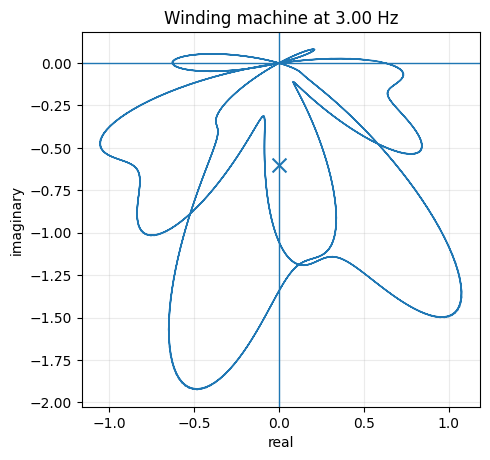

interactive(children=(FloatSlider(value=3.0, description='winding_frequency', max=40.0, step=0.25), Output()),…

In [7]:
# Optional interactive version.
# Run this cell in Jupyter after installing ipywidgets.

try:
    from ipywidgets import interact, FloatSlider

    @interact(winding_frequency=FloatSlider(value=3, min=0, max=40, step=0.25))
    def interactive_winding(winding_frequency):
        z = winding_points(t, signal, winding_frequency)
        center = z.mean()

        plt.figure(figsize=(5, 5))
        plt.plot(z.real, z.imag, linewidth=1)
        plt.scatter([center.real], [center.imag], s=100, marker="x")
        plt.axhline(0, linewidth=1)
        plt.axvline(0, linewidth=1)
        plt.gca().set_aspect("equal", adjustable="box")
        set_plot(f"Winding machine at {winding_frequency:.2f} Hz", "real", "imaginary")
        plt.show()
except Exception as e:
    print("ipywidgets is not available. Install it with: pip install ipywidgets")
    print("Original error:", repr(e))

## 5. Optional Manim animation: the winding machine

Run the next cell only if Manim is installed.

In a notebook, first import Manim, then use the `%%manim` cell magic.  
The scene below visualizes a signal wrapped around the complex plane. The yellow dot is the center of mass, i.e., the Fourier coefficient for the chosen winding frequency.

In [14]:
from manim import *

In [15]:
%%manim -qm -v WARNING WindingMachineScene

from manim import *
import numpy as np

class WindingMachineScene(Scene):
    def construct(self):
        title = Text("Fourier Transform as a winding machine", font_size=34)
        title.to_edge(UP)

        plane = ComplexPlane(
            x_range=[-1.8, 1.8, 0.5],
            y_range=[-1.8, 1.8, 0.5],
            x_length=5.2,
            y_length=5.2
        ).add_coordinates()
        plane.shift(DOWN * 0.35)

        n = 700
        t = np.linspace(0, 1, n)
        signal = 1.0*np.sin(2*np.pi*3*t) + 0.45*np.sin(2*np.pi*8*t + 0.4)
        winding_frequency = 3

        z = signal * np.exp(-1j * 2*np.pi*winding_frequency*t)
        points = [plane.n2p(complex(v.real, v.imag)) for v in z]

        curve = VMobject()
        curve.set_points_smoothly(points)
        curve.set_stroke(BLUE, width=3)

        center = z.mean()
        center_dot = Dot(plane.n2p(complex(center.real, center.imag)), color=YELLOW)
        center_label = Text("center of mass", font_size=22).next_to(center_dot, RIGHT)

        explanation = Text(
            "Correct winding frequency → lopsided wrap → nonzero center",
            font_size=24
        ).to_edge(DOWN)

        self.play(Write(title))
        self.play(Create(plane))
        self.play(Create(curve), run_time=4)
        self.play(FadeIn(center_dot), Write(center_label))
        self.play(Write(explanation))
        self.wait(2)

Manim Community v0.20.1

FileNotFoundError: [Errno 2] No such file or directory: 'latex'

## 6. The Discrete Fourier Transform from scratch

Computers do not see continuous signals. They see samples:

\[
x[0], x[1], x[2], \dots, x[N-1]
\]

The Discrete Fourier Transform, or DFT, creates a coefficient \(X[k]\) for each frequency bin \(k\):

\[
X[k] = \sum_{n=0}^{N-1} x[n]e^{-i2\pi kn/N}
\]

Interpretation:

- \(n\) = time/sample index
- \(k\) = frequency bin
- \(x[n]\) = signal sample
- \(e^{-i2\pi kn/N}\) = rotating test wave
- \(X[k]\) = amount of frequency \(k\), including magnitude and phase

This is the internal working: **many dot products against rotating waves**.

In [ ]:
def dft_slow(x):
    # Educational DFT implementation.
    # This is O(N^2), so it is slow for large N.
    x = np.asarray(x, dtype=complex)
    N = x.size
    n = np.arange(N)
    k = n.reshape((N, 1))
    W = np.exp(-2j * np.pi * k * n / N)  # DFT matrix
    return W @ x

# Use a small signal so the slow DFT is easy to inspect.
N = 64
t_small = np.arange(N) / N
x_small = (
    1.0*np.sin(2*np.pi*5*t_small)
    + 0.5*np.sin(2*np.pi*13*t_small + 0.8)
)

X_slow = dft_slow(x_small)
X_fast = np.fft.fft(x_small)

print("Max difference between slow DFT and NumPy FFT:")
print(np.max(np.abs(X_slow - X_fast)))

freq_bins = np.arange(N)

plt.figure(figsize=(12, 4))
plt.stem(freq_bins[:N//2], np.abs(X_slow[:N//2]) / N)
set_plot("DFT magnitude spectrum", "frequency bin", "magnitude")
plt.show()

### Why are there negative frequencies?

For real signals, the spectrum is symmetric.

A real sine wave can be represented as two complex rotations:

- one rotating counterclockwise
- one rotating clockwise

Those are positive and negative frequencies. This is why a pure real sine wave often appears as two mirrored peaks in the full FFT.

In [ ]:
plt.figure(figsize=(12, 4))
plt.stem(np.fft.fftfreq(N, d=1/N), np.abs(X_fast) / N)
set_plot("Full FFT spectrum with positive and negative frequency bins", "frequency bin", "magnitude")
plt.show()

## 7. Magnitude and phase: volume and timing

Each Fourier coefficient is complex.

- Magnitude = strength/volume of a frequency.
- Phase = where that frequency starts.

If you know all magnitudes and all phases, you can reconstruct the original signal exactly.

If you keep only the biggest coefficients, you get an approximation. This is the basis of many compression ideas.

In [ ]:
# Reconstruct a signal from only the largest K Fourier coefficients.

def reconstruct_with_top_k_coefficients(x, K):
    X = np.fft.fft(x)
    keep = np.zeros_like(X, dtype=bool)
    largest_indices = np.argsort(np.abs(X))[-K:]
    keep[largest_indices] = True

    X_reduced = np.where(keep, X, 0)
    x_reconstructed = np.fft.ifft(X_reduced).real
    return x_reconstructed, X_reduced

for K in [2, 4, 8, 16]:
    x_rec, _ = reconstruct_with_top_k_coefficients(signal, K)
    plt.figure(figsize=(12, 3))
    plt.plot(t, signal, label="original", linewidth=2)
    plt.plot(t, x_rec, label=f"reconstructed with top {K} coefficients")
    set_plot(f"Keeping only {K} Fourier coefficients", "time", "amplitude")
    plt.legend()
    plt.show()

## 8. Optional Manim animation: waves combine into a signal

This animation shows the “recipe” view: simple waves are ingredients, and their sum is the final signal.

In [ ]:
%%manim -qm -v WARNING WaveIngredientsScene

from manim import *
import numpy as np

class WaveIngredientsScene(Scene):
    def construct(self):
        title = Text("A signal is a recipe of waves", font_size=36).to_edge(UP)

        axes = Axes(
            x_range=[0, 4, 1],
            y_range=[-2.5, 2.5, 1],
            x_length=10,
            y_length=4.5
        ).shift(DOWN * 0.3)

        wave1 = axes.plot(lambda x: 1.0*np.sin(2*np.pi*1*x), x_range=[0, 4], color=BLUE)
        wave2 = axes.plot(lambda x: 0.55*np.sin(2*np.pi*3*x + 0.8), x_range=[0, 4], color=GREEN)
        wave3 = axes.plot(lambda x: 0.28*np.sin(2*np.pi*7*x + 1.4), x_range=[0, 4], color=RED)

        mixture = axes.plot(
            lambda x: 1.0*np.sin(2*np.pi*1*x)
                    + 0.55*np.sin(2*np.pi*3*x + 0.8)
                    + 0.28*np.sin(2*np.pi*7*x + 1.4),
            x_range=[0, 4],
            color=YELLOW
        )
        mixture.set_stroke(width=5)

        labels = VGroup(
            Text("low frequency", font_size=22, color=BLUE),
            Text("medium frequency", font_size=22, color=GREEN),
            Text("high frequency", font_size=22, color=RED),
            Text("sum / final signal", font_size=24, color=YELLOW)
        ).arrange(DOWN, aligned_edge=LEFT).to_corner(DL)

        self.play(Write(title), Create(axes))
        self.play(Create(wave1), Write(labels[0]))
        self.play(Create(wave2), Write(labels[1]))
        self.play(Create(wave3), Write(labels[2]))
        self.play(TransformFromCopy(VGroup(wave1, wave2, wave3), mixture), Write(labels[3]))
        self.wait(2)

## 9. DFT vs FFT

The DFT is the mathematical operation.

The FFT, or Fast Fourier Transform, is a family of algorithms that computes the same result much faster.

- Slow DFT: roughly \(N^2\) work.
- FFT: roughly \(N \log N\) work.

For a signal with one million samples, that difference is enormous.

In practice, when people say “take the Fourier Transform in Python,” they usually call an FFT implementation such as `np.fft.fft`, `np.fft.fft2`, or similar functions.

In [ ]:
# A tiny timing comparison.
# Exact speed depends on your machine.

import time

for N in [64, 128, 256, 512]:
    x = np.random.randn(N)

    start = time.perf_counter()
    _ = dft_slow(x)
    slow_time = time.perf_counter() - start

    start = time.perf_counter()
    _ = np.fft.fft(x)
    fast_time = time.perf_counter() - start

    print(f"N={N:4d} | slow DFT: {slow_time:.5f}s | FFT: {fast_time:.7f}s | speedup: {slow_time/fast_time:8.1f}x")

# Part II — Fourier Transform for images

An image is also a signal.

For grayscale images:

- \(x\)-axis = horizontal position
- \(y\)-axis = vertical position
- pixel value = brightness

A 2D Fourier Transform asks:

> “How much of each horizontal/vertical spatial frequency exists in this image?”

Spatial frequency means how quickly brightness changes across space.

- Low spatial frequencies: smooth regions, gradual lighting, overall shape.
- High spatial frequencies: edges, texture, fine detail, noise.

In [ ]:
# Load a sample image.
# Uses scikit-image if available; otherwise creates a synthetic image.

try:
    from skimage import data, color, img_as_float
    image = img_as_float(data.camera())
    image_source = "skimage.data.camera()"
except Exception:
    size = 256
    y, x = np.mgrid[0:size, 0:size]
    image = (
        0.4*np.sin(2*np.pi*x/32)
        + 0.4*np.sin(2*np.pi*y/48)
        + ((x-size/2)**2 + (y-size/2)**2 < (size/4)**2).astype(float)
    )
    image = normalize01(image)
    image_source = "synthetic fallback image"

print("Image source:", image_source)
print("Image shape:", image.shape)

plt.figure(figsize=(5, 5))
plt.imshow(image, cmap="gray")
plt.title("Input image")
plt.axis("off")
plt.show()

## 10. The 2D Fourier spectrum

The 2D FFT gives a complex coefficient for each 2D frequency.

To visualize it, we usually plot:

\[
\log(1 + |F|)
\]

Why log? Because the low-frequency coefficients are often much larger than the high-frequency ones.

`fftshift` moves the zero-frequency component to the center, making the spectrum easier to read:

- center = low frequencies
- far from center = high frequencies
- horizontal/vertical bright spots = repeated stripe-like patterns

In [ ]:
F = np.fft.fft2(image)
F_shifted = np.fft.fftshift(F)

magnitude_spectrum = np.log1p(np.abs(F_shifted))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(magnitude_spectrum, cmap="gray")
plt.title("Log magnitude of shifted 2D FFT")
plt.axis("off")

plt.tight_layout()
plt.show()

## 11. Image editing operation: blur using low-pass filtering

Blurring removes fine detail.

Fine detail lives in high spatial frequencies, so a simple Fourier blur is:

1. Transform image to frequency domain.
2. Keep the center low-frequency region.
3. Remove frequencies far from the center.
4. Inverse transform back to image space.

This is called **low-pass filtering**.

In [ ]:
def circular_frequency_mask(shape, radius, highpass=False):
    rows, cols = shape
    cy, cx = rows // 2, cols // 2
    y, x = np.ogrid[:rows, :cols]
    distance = np.sqrt((y - cy)**2 + (x - cx)**2)
    low = distance <= radius
    return ~low if highpass else low

def apply_frequency_mask(img, mask):
    F = np.fft.fftshift(np.fft.fft2(img))
    F_filtered = F * mask
    img_filtered = np.fft.ifft2(np.fft.ifftshift(F_filtered)).real
    return img_filtered, F_filtered

radii = [10, 25, 60]

for r in radii:
    mask = circular_frequency_mask(image.shape, radius=r, highpass=False)
    blurred, _ = apply_frequency_mask(image, mask)

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(mask, cmap="gray")
    plt.title(f"Low-pass mask, radius={r}")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(blurred, cmap="gray")
    plt.title("Blurred result")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

## 12. Image editing operation: edge extraction using high-pass filtering

Edges and textures are rapid brightness changes, so they live in high frequencies.

A simple high-pass filter removes the smooth/low-frequency part and keeps the detail.

This is related to:

- edge detection
- texture extraction
- sharpening
- local contrast enhancement

In [ ]:
radius = 25
high_mask = circular_frequency_mask(image.shape, radius=radius, highpass=True)
edges, _ = apply_frequency_mask(image, high_mask)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(high_mask, cmap="gray")
plt.title("High-pass mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(normalize01(np.abs(edges)), cmap="gray")
plt.title("High-frequency detail / edges")
plt.axis("off")

plt.tight_layout()
plt.show()

## 13. Image editing operation: sharpening by boosting high frequencies

A common sharpening idea is:

\[
\text{sharpened image} = \text{original image} + \alpha \times \text{high-frequency detail}
\]

This is similar to turning up the treble on an audio equalizer.

Be careful: boosting high frequencies can also boost noise.

In [ ]:
alpha = 1.2
detail = edges
sharpened = np.clip(image + alpha * detail, 0, 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(normalize01(np.abs(detail)), cmap="gray")
plt.title("High-frequency detail")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(sharpened, cmap="gray")
plt.title("Sharpened")
plt.axis("off")

plt.tight_layout()
plt.show()

## 14. Image compression idea: keep only the strongest frequency coefficients

Many images have most of their energy in relatively few coefficients.

A simple compression experiment:

1. Compute 2D FFT.
2. Keep only the largest coefficients by magnitude.
3. Set the rest to zero.
4. Inverse FFT.

This is not exactly JPEG, but it teaches the same broad idea: transform image data into a domain where important structure is concentrated.

In [ ]:
def keep_largest_fft_coefficients(img, keep_fraction):
    F = np.fft.fft2(img)
    magnitudes = np.abs(F)
    threshold = np.quantile(magnitudes, 1 - keep_fraction)
    F_kept = np.where(magnitudes >= threshold, F, 0)
    reconstruction = np.fft.ifft2(F_kept).real
    kept_percent = 100 * np.count_nonzero(F_kept) / F_kept.size
    return reconstruction, F_kept, kept_percent

for keep_fraction in [0.20, 0.05, 0.01]:
    reconstructed, F_kept, kept_percent = keep_largest_fft_coefficients(image, keep_fraction)

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(image, cmap="gray")
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(np.clip(reconstructed, 0, 1), cmap="gray")
    plt.title(f"Reconstruction using {kept_percent:.2f}% coefficients")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

## 15. Magnitude vs phase in images

Magnitude tells us how much of each spatial frequency exists.  
Phase tells us where structures are located.

For natural images, phase is extremely important for recognizable structure.

This experiment separates them:

- magnitude-only reconstruction
- phase-only reconstruction

The phase-only image often preserves more recognizable structure than you might expect.

In [ ]:
F = np.fft.fft2(image)
magnitude = np.abs(F)
phase = np.angle(F)

# Magnitude-only: keep magnitudes, set phase to zero.
magnitude_only_F = magnitude
magnitude_only = np.fft.ifft2(magnitude_only_F).real

# Phase-only: keep phase, set all magnitudes to 1.
phase_only_F = np.exp(1j * phase)
phase_only = np.fft.ifft2(phase_only_F).real

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(normalize01(magnitude_only), cmap="gray")
plt.title("Magnitude only")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(normalize01(phase_only), cmap="gray")
plt.title("Phase only")
plt.axis("off")

plt.tight_layout()
plt.show()

## 16. Image editing operation: removing periodic stripe noise with a notch filter

Repeating stripe noise creates bright peaks in the Fourier spectrum.

A notch filter removes small regions around those peaks while leaving most other frequencies intact.

This is useful for removing:

- scanner banding
- electrical interference patterns
- repeated texture artifacts
- periodic sensor noise

In [ ]:
# Create synthetic vertical stripe noise.
rows, cols = image.shape
x = np.arange(cols)
stripe_period = 16
stripe_noise = 0.18 * np.sin(2*np.pi*x/stripe_period)[None, :]
noisy = np.clip(image + stripe_noise, 0, 1)

F_noisy = np.fft.fftshift(np.fft.fft2(noisy))
spectrum_noisy = np.log1p(np.abs(F_noisy))

# Build notch filter around expected stripe peaks.
mask = np.ones_like(image, dtype=bool)
cy, cx = rows // 2, cols // 2
offset = int(round(cols / stripe_period))
notch_radius = 5

Y, X = np.ogrid[:rows, :cols]
for sign in [-1, 1]:
    peak_x = cx + sign * offset
    distance = np.sqrt((Y - cy)**2 + (X - peak_x)**2)
    mask[distance <= notch_radius] = False

cleaned, F_cleaned = apply_frequency_mask(noisy, mask)

plt.figure(figsize=(14, 8))

plt.subplot(2, 3, 1)
plt.imshow(image, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(noisy, cmap="gray")
plt.title("With stripe noise")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(spectrum_noisy, cmap="gray")
plt.title("Noisy FFT spectrum")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(mask, cmap="gray")
plt.title("Notch mask")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(np.log1p(np.abs(F_cleaned)), cmap="gray")
plt.title("Filtered spectrum")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(np.clip(cleaned, 0, 1), cmap="gray")
plt.title("Cleaned image")
plt.axis("off")

plt.tight_layout()
plt.show()

## 17. How Fourier ideas appear in real image editing

Fourier Transform is not always visible to the user, but its ideas are everywhere.

### Blur
Blur removes high frequencies.  
Gaussian blur is more commonly done with convolution, but by the convolution theorem, convolution in image space corresponds to multiplication in frequency space.

### Sharpen
Sharpening boosts high frequencies or subtracts a blurred version from the original.

### Denoise
Some noise occupies identifiable frequencies. Periodic noise is especially easy to spot in the Fourier spectrum.

### Compression
Transform coding tries to represent the image using fewer important coefficients. JPEG uses a related transform called the DCT, which behaves like a cosine-only Fourier cousin on small image blocks.

### Resizing and resampling
Fourier analysis helps explain aliasing: when high frequencies are sampled too coarsely, they masquerade as false low frequencies.

### Deconvolution and restoration
If an image is blurred by a known blur kernel, frequency-domain division can help undo the blur. This is delicate because noise can be amplified.

## 18. Big-picture summary

The Fourier Transform is a change of perspective.

In the original domain:

- audio is amplitude over time
- images are brightness over space
- signals may look complicated

In the Fourier domain:

- we see the wave ingredients
- low frequencies show slow changes
- high frequencies show fast changes
- magnitude shows strength
- phase shows alignment/location

The transform is powerful because many operations become easier in the frequency domain:

| Goal | Fourier-domain action |
|---|---|
| Blur image | remove high frequencies |
| Sharpen image | boost high frequencies |
| Remove periodic stripes | notch out spike frequencies |
| Compress | keep strongest/important coefficients |
| Analyze audio pitch | find spectral peaks |
| Detect repeated patterns | look for bright spots in spectrum |

## 19. Mini exercises

Try these:

1. Change the signal frequencies in Section 1 and see where the spectrum peaks move.
2. Change the winding frequency in Section 4 and watch when the center of mass moves away from zero.
3. Make the signal noisier and see if the FFT can still identify the main frequencies.
4. In image low-pass filtering, change the radius and observe the blur strength.
5. In high-pass filtering, change the radius and observe which edges remain.
6. In compression, try keeping only 0.5% of coefficients.
7. In stripe removal, change `stripe_period`, `offset`, and `notch_radius`.
8. Modify the Manim scenes to animate multiple winding frequencies side by side.

## 20. References and useful docs

- Manim Community documentation: Jupyter notebook support and `%%manim` magic.
- NumPy FFT documentation: `np.fft.fft`, `np.fft.fft2`, `np.fft.fftfreq`, and `np.fft.fftshift`.
- scikit-image documentation: sample image data and image-processing utilities.
- Further learning ideas:
  - 3Blue1Brown’s visual explanation of Fourier transforms.
  - Any DSP textbook section on DFT/FFT.
  - Image processing chapters on frequency-domain filtering.